# Notebook 02 v2 — Modèle 1 : Isolation Forest (corrigé)

**Projet :** Orange Money — Système ML Fraude & Revenue Assurance  
**Auteur :** Koceila SALEM — RA&FM

## Corrections appliquées vs v1

| # | Problème v1 | Correction v2 |
|---|-------------|---------------|
| 1 | `INITIATOR_MSISDN` NaN sur alertes critiques | Fallback sur `SENDER_USER_ID` pour le Bloc C + flag `f_has_msisdn` |
| 2 | Règle R2 capte 12.8% (RC avec `SENDER_PRE_BAL=0`) | Ratio montant/solde désactivé pour RC et CASHIN |
| 3 | Bloc C : 499 680 NaN → imputés médiane = pas de signal | Bloc C recalculé sur `SENDER_USER_ID` (toujours rempli) |

## Plan
1. Configuration & chargement
2. Parsing temporel
3. Bloc A — transactionnel (ratio corrigé)
4. Bloc B — temporel
5. Bloc C — comportemental (sur SENDER_USER_ID)
6. Bloc D — contextuel (+ TRANSFER_SUBTYPE, TRANSACTION_TAG, REQUEST_SOURCE, GATEWAY_TYPE)
7. Préparation & scaling
8. Entraînement Isolation Forest
9. Score 0–100 & seuils
10. Calibration (pseudo-labels corrigés)
11. Analyse des alertes
12. Importance des features
13. Export

## 0. Configuration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings, joblib, json
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import precision_recall_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ============================================================
# PARAMÈTRES
# ============================================================
CSV_PATH    = r'C:\Users\RQKB6834\Downloads\OM_Koceila\OM_Koceila.csv.csv'
ENCODING    = 'latin-1'
SEPARATEUR  = '|'
SAMPLE_SIZE = 500_000
RANDOM_SEED = 42
OUTPUT_DIR  = Path('outputs/M1_fraude_v2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# COLONNES RÉELLES (validées dans les notebooks précédents)
# ============================================================
COL_MONTANT    = 'TRANSACTION_AMOUNT'
COL_S_AVANT    = 'SENDER_PRE_BAL'
COL_S_APRES    = 'SENDER_POST_BAL'
COL_R_AVANT    = 'RECEIVER_PRE_BAL'
COL_R_APRES    = 'RECEIVER_POST_BAL'
COL_STATUT     = 'TRANSFER_STATUS'
COL_SERVICE    = 'SERVICE_TYPE'
COL_ERREUR     = 'ERROR_CODE'
COL_DATE       = 'CREATED_ON'
COL_SENDER_ID  = 'SENDER_USER_ID'      # FIX 3 : toujours rempli → base du Bloc C
COL_MSISDN     = 'INITIATOR_MSISDN'    # souvent NaN pour les transactions système
COL_RECVR      = 'OTHER_MSISDN'
COL_RECVR_ID   = 'RECEIVER_USER_ID'
COL_VILLE      = 'SENDER_CITY'
COL_IS_FIN     = 'IS_FINANCIAL'
COL_ATTEMPT    = 'ATTEMPT_STATUS'
COL_SENDER_ST  = 'SENDER_ACC_STATUS'
COL_RECVR_ST   = 'RECEIVER_ACC_STATUS'
COL_SUBTYPE    = 'TRANSFER_SUBTYPE'    # nouveau
COL_TAG        = 'TRANSACTION_TAG'     # nouveau
COL_REQ_SRC    = 'REQUEST_SOURCE'      # nouveau — vrai canal
COL_GATEWAY    = 'GATEWAY_TYPE'        # nouveau — vrai canal
COL_TXNMODE    = 'TXNMODE'             # nouveau
COL_USER_TYPE_S= 'SENDER_USER_TYPE'    # nouveau
COL_USER_TYPE_R= 'RECEIVER_USER_TYPE'  # nouveau

# Services dont le SENDER_PRE_BAL est structurellement 0 → exclure du ratio
SERVICES_SANS_SOLDE = ['RC', 'CASHIN', 'B2BCASHOUT', 'ENT2REG']

print('Configuration chargée.')
print(f'Output : {OUTPUT_DIR.resolve()}')

Configuration chargée.
Output : C:\Users\RQKB6834\OneDrive - orange.com\Bureau\Alternance\ML\outputs\M1_fraude_v2


## 1. Chargement & vérifications

In [14]:
debut = time.time()
df = pd.read_csv(
    CSV_PATH, sep=SEPARATEUR, encoding=ENCODING,
    nrows=SAMPLE_SIZE, low_memory=False, on_bad_lines='warn'
)
print(f'Chargé en {time.time()-debut:.1f}s — {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

# --- Diagnostic INITIATOR_MSISDN vs SENDER_USER_ID ---
print('\n=== FIX 3 : Diagnostic des identifiants compte ===')
for col in [COL_MSISDN, COL_SENDER_ID, COL_RECVR, COL_RECVR_ID]:
    if col in df.columns:
        pct_non_null = df[col].notna().mean() * 100
        n_uniques    = df[col].nunique()
        print(f'  {col:<25} : {pct_non_null:.1f}% rempli | {n_uniques:,} valeurs uniques')

# --- Diagnostic REQUEST_SOURCE et GATEWAY_TYPE (vrais canaux) ---
print('\n=== Canal d\'accès ===')
for col in [COL_REQ_SRC, COL_GATEWAY, COL_TXNMODE]:
    if col in df.columns:
        vc = df[col].value_counts().head(8)
        print(f'  {col} ({df[col].nunique()} modalités) :')
        print(f'    {vc.to_dict()}')

# --- Diagnostic TRANSFER_SUBTYPE et TRANSACTION_TAG ---
print('\n=== Nouvelles features contextuelles ===')
for col in [COL_SUBTYPE, COL_TAG, COL_USER_TYPE_S, COL_USER_TYPE_R]:
    if col in df.columns:
        vc = df[col].value_counts().head(6)
        pct_null = df[col].isna().mean() * 100
        print(f'  {col} ({df[col].nunique()} val, {pct_null:.1f}% NaN) : {vc.to_dict()}')

Chargé en 10.1s — 500,000 lignes × 80 colonnes

=== FIX 3 : Diagnostic des identifiants compte ===
  INITIATOR_MSISDN          : 0.1% rempli | 4 valeurs uniques
  SENDER_USER_ID            : 100.0% rempli | 183,319 valeurs uniques
  OTHER_MSISDN              : 26.1% rempli | 112,111 valeurs uniques
  RECEIVER_USER_ID          : 99.7% rempli | 112,355 valeurs uniques

=== Canal d'accès ===
  REQUEST_SOURCE (1 modalités) :
    {'BROWSER': 498418}
  GATEWAY_TYPE (2 modalités) :
    {'USSD': 459312, 'WEB': 39105}
  TXNMODE (59849 modalités) :
    {'W2B': 13400, '02': 836, '01#ECOMMERCE#TRN#1MPAYMENT#MG#MGA#1758352986#v1m1mlbeqmik69d9f5il#02#0': 6, '01#ECOMMERCE#TRN#1MPAYMENT#MG#MGA#1758323982#v1j3ub9m56abbvqcug1v#02#0': 3, '01#ECOMMERCE#TRN#1MPAYMENT#MG#MGA#1758369955#v1nwwcyxdhh1ksc4eyn1#02#0': 3, '01#ECOMMERCE#TRN#1MPAYMENT#MG#MGA#1758337370#v1h6h1k6bscqyizqvzzr#02#0': 3, '01#ECOMMERCE#TRN#1MPAYMENT#MG#MGA#1758349112#v1m5y5pgzjbmirgm35nt#02#0': 3, '01#ECOMMERCE#TRN#1MPAYMENT#MG#MGA#17583

## 2. Parsing temporel & cast numérique

In [15]:
# Dates
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce', dayfirst=True)
df['_heure']  = df[COL_DATE].dt.hour
df['_minute'] = df[COL_DATE].dt.minute
print(f'Plage : {df[COL_DATE].min()} → {df[COL_DATE].max()}')

# Cast numérique
COLS_NUM = [COL_MONTANT, COL_S_AVANT, COL_S_APRES,
            COL_R_AVANT, COL_R_APRES, COL_ERREUR,
            'COMMISSIONS_PAID', 'COMMISSIONS_RECEIVED',
            'SERVICE_CHARGE_RECEIVED', 'SERVICE_CHARGE_PAID']
COLS_NUM = [c for c in COLS_NUM if c in df.columns]
for col in COLS_NUM:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# SENDER_USER_ID en string propre (pour le groupby Bloc C)
df[COL_SENDER_ID] = df[COL_SENDER_ID].astype(str).str.strip()
df[COL_RECVR_ID]  = df[COL_RECVR_ID].astype(str).str.strip()

print('Cast numérique OK.')
print(f'\nSERVICE_TYPE :')
print(df[COL_SERVICE].value_counts().to_dict())

Plage : 2025-09-20 00:00:00 → 2025-09-20 15:42:15
Cast numérique OK.

SERVICE_TYPE :
{'RC': 144497, 'MERCHPAY': 114607, 'CASHOUT': 89861, 'CASHIN': 86874, 'P2P': 62572, 'ROLLBACK': 1170, 'TXNCORRECT': 313, 'B2BCASHOUT': 94, 'OPTW': 6, 'ENT2REG': 4, 'O2C': 1, 'COUTBYCODE': 1}


## 3. Bloc A — Features transactionnelles (ratio corrigé)

**FIX 2 :** Le ratio `montant / solde_avant` est mis à `-2` (valeur sentinelle "non applicable")  
pour les services RC, CASHIN, B2BCASHOUT, ENT2REG dont le `SENDER_PRE_BAL` est structurellement 0.

In [16]:
df_feat = df.copy()

# A1. Log montant
df_feat['f_log_montant'] = np.log1p(df_feat[COL_MONTANT].clip(lower=0))

# A2. Ratio montant / solde avant — CORRIGÉ
# Pour RC/CASHIN : SENDER_PRE_BAL=0 est normal → on met -2 (sentinelle "N/A")
# Pour les autres : ratio réel capped à [0, 10]
mask_sans_solde = df_feat[COL_SERVICE].isin(SERVICES_SANS_SOLDE)
df_feat['f_ratio_montant_solde'] = np.where(
    mask_sans_solde,
    -2,   # sentinelle = service sans solde émetteur significatif
    np.where(
        df_feat[COL_S_AVANT] > 0,
        (df_feat[COL_MONTANT] / (df_feat[COL_S_AVANT] + 1)).clip(0, 10),
        -1   # solde nul pour un service qui devrait en avoir un = signal fort
    )
)

print('FIX 2 — Vérification ratio par service :')
print(df_feat.groupby(COL_SERVICE)['f_ratio_montant_solde'].agg(['mean','min','max']).round(3))

# A3. Delta solde émetteur
df_feat['f_delta_solde']       = df_feat[COL_S_APRES] - df_feat[COL_S_AVANT]
df_feat['f_incoherence_solde'] = np.abs(df_feat['f_delta_solde'] + df_feat[COL_MONTANT])
df_feat['f_log_incoherence']   = np.log1p(df_feat['f_incoherence_solde'].clip(lower=0))

# A4. Solde après nul
df_feat['f_solde_apres_nul']   = (df_feat[COL_S_APRES] <= 0).astype(int)

# A5. Montants ronds
df_feat['f_montant_arrondi']      = (df_feat[COL_MONTANT] % 1_000  == 0).astype(int)
df_feat['f_montant_tres_arrondi'] = (df_feat[COL_MONTANT] % 10_000 == 0).astype(int)

# A6. Solde avant faible (< 1 000) pour service avec solde
df_feat['f_solde_avant_faible'] = np.where(
    mask_sans_solde, 0,
    (df_feat[COL_S_AVANT] < 1_000).astype(int)
)

# A7. Log solde avant
df_feat['f_log_solde_avant'] = np.log1p(df_feat[COL_S_AVANT].clip(lower=0))

# A8. Cohérence solde récepteur
df_feat['f_delta_solde_recvr'] = df_feat[COL_R_APRES] - df_feat[COL_R_AVANT]
df_feat['f_incoherence_recvr'] = np.log1p(
    np.abs(df_feat['f_delta_solde_recvr'] - df_feat[COL_MONTANT]).clip(lower=0)
)

# A9. FIX 1 : flag transaction sans MSISDN client (= transaction système / opérateur)
df_feat['f_has_msisdn'] = df_feat[COL_MSISDN].notna().astype(int)
print(f'\nFIX 1 — Transactions avec MSISDN : {df_feat["f_has_msisdn"].sum():,} ({df_feat["f_has_msisdn"].mean()*100:.1f}%)')
print(f'         Transactions sans MSISDN  : {(df_feat["f_has_msisdn"]==0).sum():,} — répartition par service :')
print(df_feat[df_feat['f_has_msisdn']==0][COL_SERVICE].value_counts().head(8).to_dict())

feats_A = [c for c in df_feat.columns if c.startswith('f_') and
           any(k in c for k in ['montant','solde','ratio','delta','inco','log_s','msisdn'])]
print(f'\n✅ Bloc A — {len(feats_A)} features : {feats_A}')

FIX 2 — Vérification ratio par service :
                mean     min     max
SERVICE_TYPE                        
B2BCASHOUT   -2.0000 -2.0000 -2.0000
CASHIN       -2.0000 -2.0000 -2.0000
CASHOUT       0.8780 -1.0000 10.0000
COUTBYCODE   -1.0000 -1.0000 -1.0000
ENT2REG      -2.0000 -2.0000 -2.0000
MERCHPAY      0.4650 -1.0000 10.0000
O2C           0.0000  0.0000  0.0000
OPTW          0.3110  0.0080  1.0000
P2P           0.4810 -1.0000 10.0000
RC           -2.0000 -2.0000 -2.0000
ROLLBACK      0.0000  0.0000  0.0000
TXNCORRECT    0.0000  0.0000  0.0000

FIX 1 — Transactions avec MSISDN : 320 (0.1%)
         Transactions sans MSISDN  : 499,680 — répartition par service :
{'RC': 144497, 'MERCHPAY': 114607, 'CASHOUT': 89861, 'CASHIN': 86874, 'P2P': 62572, 'ROLLBACK': 1170, 'B2BCASHOUT': 94, 'ENT2REG': 4}

✅ Bloc A — 13 features : ['f_log_montant', 'f_ratio_montant_solde', 'f_delta_solde', 'f_incoherence_solde', 'f_log_incoherence', 'f_solde_apres_nul', 'f_montant_arrondi', 'f_montant_tres

## 4. Bloc B — Features temporelles

In [17]:
df_feat['f_heure_sin']  = np.sin(2 * np.pi * df_feat['_heure'] / 24)
df_feat['f_heure_cos']  = np.cos(2 * np.pi * df_feat['_heure'] / 24)
df_feat['f_est_nuit']   = df_feat['_heure'].between(0, 5).astype(int)
df_feat['f_est_soiree'] = df_feat['_heure'].between(20, 23).astype(int)
df_feat['f_minute_sin'] = np.sin(2 * np.pi * df_feat['_minute'] / 60)
df_feat['f_minute_cos'] = np.cos(2 * np.pi * df_feat['_minute'] / 60)
# f_est_weekend non créée : échantillon = 1 seul jour (samedi)

feats_B = [c for c in df_feat.columns if c.startswith('f_') and
           any(k in c for k in ['heure','nuit','soiree','minute'])]
print(f'✅ Bloc B — {len(feats_B)} features : {feats_B}')

✅ Bloc B — 6 features : ['f_heure_sin', 'f_heure_cos', 'f_est_nuit', 'f_est_soiree', 'f_minute_sin', 'f_minute_cos']


## 5. Bloc C — Features comportementales (FIX 3 : sur SENDER_USER_ID)

**FIX 3 :** `INITIATOR_MSISDN` est NaN pour ~50% des transactions (transactions système).  
On recalcule le Bloc C sur `SENDER_USER_ID` qui est **toujours rempli** (100% non-null).

In [18]:
print(f'FIX 3 — Utilisation de {COL_SENDER_ID} pour le Bloc C')
print(f'  Taux rempli : {df_feat[COL_SENDER_ID].notna().mean()*100:.1f}%')
print(f'  Comptes uniques : {df_feat[COL_SENDER_ID].nunique():,}')

print('\nCalcul Bloc C...')
debut = time.time()

# Tri par compte + date
df_feat = df_feat.sort_values([COL_SENDER_ID, COL_DATE]).reset_index(drop=True)

# C1. Rang de la transaction dans la journée pour ce compte
df_feat['f_rang_tx_compte'] = (
    df_feat.groupby(COL_SENDER_ID).cumcount()
).clip(upper=500)

# C2. Nombre de transactions cumulées dans la journée
df_feat['f_nb_tx_journee'] = df_feat['f_rang_tx_compte'] + 1

# C3. Montant cumulé envoyé dans la journée
df_feat['f_montant_cumul_journee'] = (
    df_feat.groupby(COL_SENDER_ID)[COL_MONTANT]
    .transform(lambda x: x.expanding().sum())
)
df_feat['f_log_montant_cumul'] = np.log1p(df_feat['f_montant_cumul_journee'].clip(lower=0))

# C4. Nombre de destinataires distincts dans la journée
def _cum_nunique(s):
    seen = set()
    out = []
    for v in s:
        seen.add(v)
        out.append(len(seen))
    return out

df_feat['f_nb_dest_journee'] = (
    df_feat.groupby(COL_SENDER_ID)[COL_RECVR_ID]
    .transform(lambda s: pd.Series(_cum_nunique(s), index=s.index))
).clip(upper=200)

# C5. Taux d'échec cumulé dans la journée
df_feat['_is_failed'] = (df_feat[COL_STATUT] == 'TF').astype(int)
df_feat['f_taux_echec_journee'] = (
    df_feat.groupby(COL_SENDER_ID)['_is_failed']
    .transform(lambda x: x.expanding().mean())
)
df_feat.drop(columns=['_is_failed'], inplace=True)

# C6. Écart-type des montants (variance intra-compte)
df_feat['f_std_montant_compte'] = (
    df_feat.groupby(COL_SENDER_ID)[COL_MONTANT]
    .transform(lambda x: x.expanding().std().fillna(0))
)
df_feat['f_log_std_montant'] = np.log1p(df_feat['f_std_montant_compte'].clip(lower=0))

# C7. Ratio montant courant / moyenne historique du compte
df_feat['_mean_compte'] = (
    df_feat.groupby(COL_SENDER_ID)[COL_MONTANT]
    .transform(lambda x: x.expanding().mean())
)
df_feat['f_ratio_vs_moy_compte'] = np.where(
    df_feat['_mean_compte'] > 0,
    (df_feat[COL_MONTANT] / (df_feat['_mean_compte'] + 1)).clip(0, 50),
    1
)
df_feat.drop(columns=['_mean_compte'], inplace=True)

# C8. Nombre de services distincts utilisés dans la journée
df_feat['f_nb_services_distincts'] = (
    df_feat.groupby(COL_SENDER_ID)[COL_SERVICE]
    .transform(lambda s: pd.Series(_cum_nunique(s), index=s.index))
).clip(upper=200)

print(f'✅ Bloc C — créé en {time.time()-debut:.1f}s')

# Vérification NaN
feats_C = ['f_rang_tx_compte','f_nb_tx_journee','f_montant_cumul_journee',
           'f_log_montant_cumul','f_nb_dest_journee','f_taux_echec_journee',
           'f_std_montant_compte','f_log_std_montant','f_ratio_vs_moy_compte',
           'f_nb_services_distincts']
nan_check = df_feat[feats_C].isna().sum()
print(f'\nVérification NaN Bloc C (attendu : 0 ou quasi) :')
print(nan_check)

FIX 3 — Utilisation de SENDER_USER_ID pour le Bloc C
  Taux rempli : 100.0%
  Comptes uniques : 183,320

Calcul Bloc C...
✅ Bloc C — créé en 233.8s

Vérification NaN Bloc C (attendu : 0 ou quasi) :
f_rang_tx_compte           0
f_nb_tx_journee            0
f_montant_cumul_journee    0
f_log_montant_cumul        0
f_nb_dest_journee          0
f_taux_echec_journee       0
f_std_montant_compte       0
f_log_std_montant          0
f_ratio_vs_moy_compte      0
f_nb_services_distincts    0
dtype: int64


## 6. Bloc D — Features contextuelles (enrichi)

In [19]:
# D1. TRANSFER_STATUS
statut_dummies = pd.get_dummies(df_feat[COL_STATUT], prefix='f_statut')
df_feat = pd.concat([df_feat, statut_dummies], axis=1)
print(f'✅ D1. TRANSFER_STATUS → {list(statut_dummies.columns)}')

# D2. SERVICE_TYPE fréquence
freq_service = df_feat[COL_SERVICE].value_counts(normalize=True)
df_feat['f_service_freq'] = df_feat[COL_SERVICE].map(freq_service)
print(f'✅ D2. SERVICE_TYPE fréquence ({df_feat[COL_SERVICE].nunique()} modalités)')

# D3. ERROR_CODE
df_feat['f_has_error'] = df_feat[COL_ERREUR].notna().astype(int)
print(f'✅ D3. ERROR_CODE → f_has_error')

# D4. IS_FINANCIAL
df_feat['f_is_financial'] = (df_feat[COL_IS_FIN] == 'Y').astype(int)
print(f'✅ D4. IS_FINANCIAL')

# D5. SENDER_CITY fréquence
if COL_VILLE in df_feat.columns:
    freq_ville = df_feat[COL_VILLE].value_counts(normalize=True)
    df_feat['f_ville_freq'] = df_feat[COL_VILLE].map(freq_ville).fillna(0)
    print(f'✅ D5. SENDER_CITY fréquence ({df_feat[COL_VILLE].nunique()} villes)')

# D6. REQUEST_SOURCE — vrai canal (USSD, API, WEB...)
if COL_REQ_SRC in df_feat.columns:
    n = df_feat[COL_REQ_SRC].nunique()
    if n <= 20:
        req_dummies = pd.get_dummies(df_feat[COL_REQ_SRC], prefix='f_req_src')
        df_feat = pd.concat([df_feat, req_dummies], axis=1)
        print(f'✅ D6. REQUEST_SOURCE → OHE {n} modalités : {list(req_dummies.columns)}')
    else:
        freq_req = df_feat[COL_REQ_SRC].value_counts(normalize=True)
        df_feat['f_req_src_freq'] = df_feat[COL_REQ_SRC].map(freq_req).fillna(0)
        print(f'✅ D6. REQUEST_SOURCE → fréquence encoding ({n} modalités)')

# D7. GATEWAY_TYPE
if COL_GATEWAY in df_feat.columns:
    n = df_feat[COL_GATEWAY].nunique()
    if n <= 20:
        gw_dummies = pd.get_dummies(df_feat[COL_GATEWAY], prefix='f_gateway')
        df_feat = pd.concat([df_feat, gw_dummies], axis=1)
        print(f'✅ D7. GATEWAY_TYPE → OHE {n} modalités : {list(gw_dummies.columns)}')
    else:
        freq_gw = df_feat[COL_GATEWAY].value_counts(normalize=True)
        df_feat['f_gateway_freq'] = df_feat[COL_GATEWAY].map(freq_gw).fillna(0)
        print(f'✅ D7. GATEWAY_TYPE → fréquence encoding ({n} modalités)')

# D8. TRANSFER_SUBTYPE
if COL_SUBTYPE in df_feat.columns and df_feat[COL_SUBTYPE].notna().sum() > 1000:
    n = df_feat[COL_SUBTYPE].nunique()
    if n <= 30:
        sub_dummies = pd.get_dummies(df_feat[COL_SUBTYPE], prefix='f_subtype')
        df_feat = pd.concat([df_feat, sub_dummies], axis=1)
        print(f'✅ D8. TRANSFER_SUBTYPE → OHE {n} modalités')
    else:
        freq_sub = df_feat[COL_SUBTYPE].value_counts(normalize=True)
        df_feat['f_subtype_freq'] = df_feat[COL_SUBTYPE].map(freq_sub).fillna(0)
        print(f'✅ D8. TRANSFER_SUBTYPE → fréquence ({n} modalités)')

# D9. TRANSACTION_TAG
if COL_TAG in df_feat.columns and df_feat[COL_TAG].notna().sum() > 1000:
    n = df_feat[COL_TAG].nunique()
    if n <= 30:
        tag_dummies = pd.get_dummies(df_feat[COL_TAG], prefix='f_tag')
        df_feat = pd.concat([df_feat, tag_dummies], axis=1)
        print(f'✅ D9. TRANSACTION_TAG → OHE {n} modalités')
    else:
        freq_tag = df_feat[COL_TAG].value_counts(normalize=True)
        df_feat['f_tag_freq'] = df_feat[COL_TAG].map(freq_tag).fillna(0)
        print(f'✅ D9. TRANSACTION_TAG → fréquence ({n} modalités)')

# D10. TXNMODE
if COL_TXNMODE in df_feat.columns and df_feat[COL_TXNMODE].notna().sum() > 1000:
    n = df_feat[COL_TXNMODE].nunique()
    if n <= 15:
        txn_dummies = pd.get_dummies(df_feat[COL_TXNMODE], prefix='f_txnmode')
        df_feat = pd.concat([df_feat, txn_dummies], axis=1)
        print(f'✅ D10. TXNMODE → OHE {n} modalités : {list(txn_dummies.columns)}')
    else:
        freq_txn = df_feat[COL_TXNMODE].value_counts(normalize=True)
        df_feat['f_txnmode_freq'] = df_feat[COL_TXNMODE].map(freq_txn).fillna(0)
        print(f'✅ D10. TXNMODE → fréquence ({n} modalités)')

# D11. SENDER_USER_TYPE / RECEIVER_USER_TYPE
for col, prefix in [(COL_USER_TYPE_S, 'f_sender_type'), (COL_USER_TYPE_R, 'f_recvr_type')]:
    if col in df_feat.columns and df_feat[col].notna().sum() > 1000:
        n = df_feat[col].nunique()
        if n <= 15:
            dummies = pd.get_dummies(df_feat[col], prefix=prefix)
            df_feat = pd.concat([df_feat, dummies], axis=1)
            print(f'✅ D11. {col} → OHE {n} modalités')

# D12. SENDER_ACC_STATUS / RECEIVER_ACC_STATUS
for col, prefix in [(COL_SENDER_ST, 'f_sender_status'), (COL_RECVR_ST, 'f_recvr_status')]:
    if col in df_feat.columns:
        dummies = pd.get_dummies(df_feat[col], prefix=prefix)
        df_feat = pd.concat([df_feat, dummies], axis=1)
        print(f'✅ D12. {col} → {list(dummies.columns)}')

# D13. ATTEMPT_STATUS
if COL_ATTEMPT in df_feat.columns:
    att_dummies = pd.get_dummies(df_feat[COL_ATTEMPT], prefix='f_attempt')
    df_feat = pd.concat([df_feat, att_dummies], axis=1)
    print(f'✅ D13. ATTEMPT_STATUS → {list(att_dummies.columns)}')

✅ D1. TRANSFER_STATUS → ['f_statut_A1', 'f_statut_TF', 'f_statut_TI', 'f_statut_TPI', 'f_statut_TS']
✅ D2. SERVICE_TYPE fréquence (12 modalités)
✅ D3. ERROR_CODE → f_has_error
✅ D4. IS_FINANCIAL
✅ D5. SENDER_CITY fréquence (12822 villes)
✅ D6. REQUEST_SOURCE → OHE 1 modalités : ['f_req_src_BROWSER']
✅ D7. GATEWAY_TYPE → OHE 2 modalités : ['f_gateway_USSD', 'f_gateway_WEB']
✅ D8. TRANSFER_SUBTYPE → OHE 13 modalités
✅ D9. TRANSACTION_TAG → fréquence (32 modalités)
✅ D10. TXNMODE → fréquence (59849 modalités)
✅ D11. SENDER_USER_TYPE → OHE 4 modalités
✅ D11. RECEIVER_USER_TYPE → OHE 4 modalités
✅ D12. SENDER_ACC_STATUS → ['f_sender_status_Y']
✅ D12. RECEIVER_ACC_STATUS → ['f_recvr_status_Y']
✅ D13. ATTEMPT_STATUS → ['f_attempt_No Response', 'f_attempt_Request Cancelled', 'f_attempt_Request Confirmed']


In [20]:
# Récapitulatif des features
FEATURE_COLS = [c for c in df_feat.columns if c.startswith('f_')]

blocs = {
    'A - Transactionnel': [c for c in FEATURE_COLS if any(k in c for k in
        ['montant','solde','ratio','delta','inco','log_s','msisdn'])],
    'B - Temporel'      : [c for c in FEATURE_COLS if any(k in c for k in
        ['heure','nuit','soiree','minute'])],
    'C - Comportemental': [c for c in FEATURE_COLS if any(k in c for k in
        ['rang','nb_tx','cumul','dest','echec','std','ratio_vs_moy','nb_services'])],
    'D - Contextuel'    : [c for c in FEATURE_COLS if any(k in c for k in
        ['statut','service','has_error','financial','ville','req_src','gateway',
         'subtype','tag','txnmode','sender_type','recvr_type','sender_status',
         'recvr_status','attempt'])],
}

print(f'\n==== FEATURES FINALES v2 : {len(FEATURE_COLS)} ====')
for bloc, cols in blocs.items():
    print(f'\n{bloc} ({len(cols)}) :')
    for c in cols:
        print(f'  {c}')


==== FEATURES FINALES v2 : 69 ====

A - Transactionnel (18) :
  f_log_montant
  f_ratio_montant_solde
  f_delta_solde
  f_incoherence_solde
  f_log_incoherence
  f_solde_apres_nul
  f_montant_arrondi
  f_montant_tres_arrondi
  f_solde_avant_faible
  f_log_solde_avant
  f_delta_solde_recvr
  f_incoherence_recvr
  f_has_msisdn
  f_montant_cumul_journee
  f_log_montant_cumul
  f_std_montant_compte
  f_log_std_montant
  f_ratio_vs_moy_compte

B - Temporel (6) :
  f_heure_sin
  f_heure_cos
  f_est_nuit
  f_est_soiree
  f_minute_sin
  f_minute_cos

C - Comportemental (10) :
  f_rang_tx_compte
  f_nb_tx_journee
  f_montant_cumul_journee
  f_log_montant_cumul
  f_nb_dest_journee
  f_taux_echec_journee
  f_std_montant_compte
  f_log_std_montant
  f_ratio_vs_moy_compte
  f_nb_services_distincts

D - Contextuel (41) :
  f_nb_services_distincts
  f_statut_A1
  f_statut_TF
  f_statut_TI
  f_statut_TPI
  f_statut_TS
  f_service_freq
  f_has_error
  f_is_financial
  f_ville_freq
  f_req_src_BROWSER


## 7. Préparation du dataset & scaling

In [21]:
df_model = df_feat[FEATURE_COLS].copy()

# Vérification NaN
nan_counts = df_model.isna().sum()
cols_nan = nan_counts[nan_counts > 0]
if len(cols_nan) > 0:
    print(f'Colonnes avec NaN ({len(cols_nan)}) :')
    print(cols_nan)
    df_model = df_model.fillna(df_model.median())
    print('→ Imputées avec la médiane.')
else:
    print('✅ Aucun NaN.')

# Vérification colonnes constantes (inutiles pour IF)
constantes = [c for c in FEATURE_COLS if df_model[c].std() == 0]
if constantes:
    print(f'\n⚠️  Colonnes constantes supprimées : {constantes}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in constantes]
    df_model = df_model[FEATURE_COLS]

print(f'\nDataset final : {df_model.shape[0]:,} lignes × {df_model.shape[1]} features')

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model)
print('✅ RobustScaler appliqué.')

✅ Aucun NaN.

⚠️  Colonnes constantes supprimées : ['f_est_soiree', 'f_is_financial']

Dataset final : 500,000 lignes × 67 features
✅ RobustScaler appliqué.


## 8. Entraînement Isolation Forest

In [22]:
print('Entraînement Isolation Forest v2...')
debut = time.time()

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    max_samples='auto',
    max_features=1.0,
    bootstrap=False,
    n_jobs=-1,
    random_state=RANDOM_SEED
)
iso_forest.fit(X_scaled)
print(f'✅ Entraîné en {time.time()-debut:.1f}s')

scores_bruts = iso_forest.score_samples(X_scaled)
predictions  = iso_forest.predict(X_scaled)

n_anomalies = (predictions == -1).sum()
print(f'Anomalies (contamination=1%) : {n_anomalies:,}')
print(f'Score brut — min: {scores_bruts.min():.4f} | moy: {scores_bruts.mean():.4f} | max: {scores_bruts.max():.4f}')

Entraînement Isolation Forest v2...
✅ Entraîné en 9.8s
Anomalies (contamination=1%) : 5,000
Score brut — min: -0.7062 | moy: -0.4389 | max: -0.3698


## 9. Normalisation score 0–100 & seuils

Distribution du RISK_SCORE v2 :
count   500,000.0000
mean         20.5300
std          15.4200
min           0.0000
50%          15.0100
75%          25.8900
90%          46.6700
95%          54.3300
99%          66.7600
max         100.0000
dtype: float64

Répartition par niveau :
RISK_LEVEL
Normal      496551
Modéré        3285
Élevé          158
Critique         6
Name: count, dtype: int64


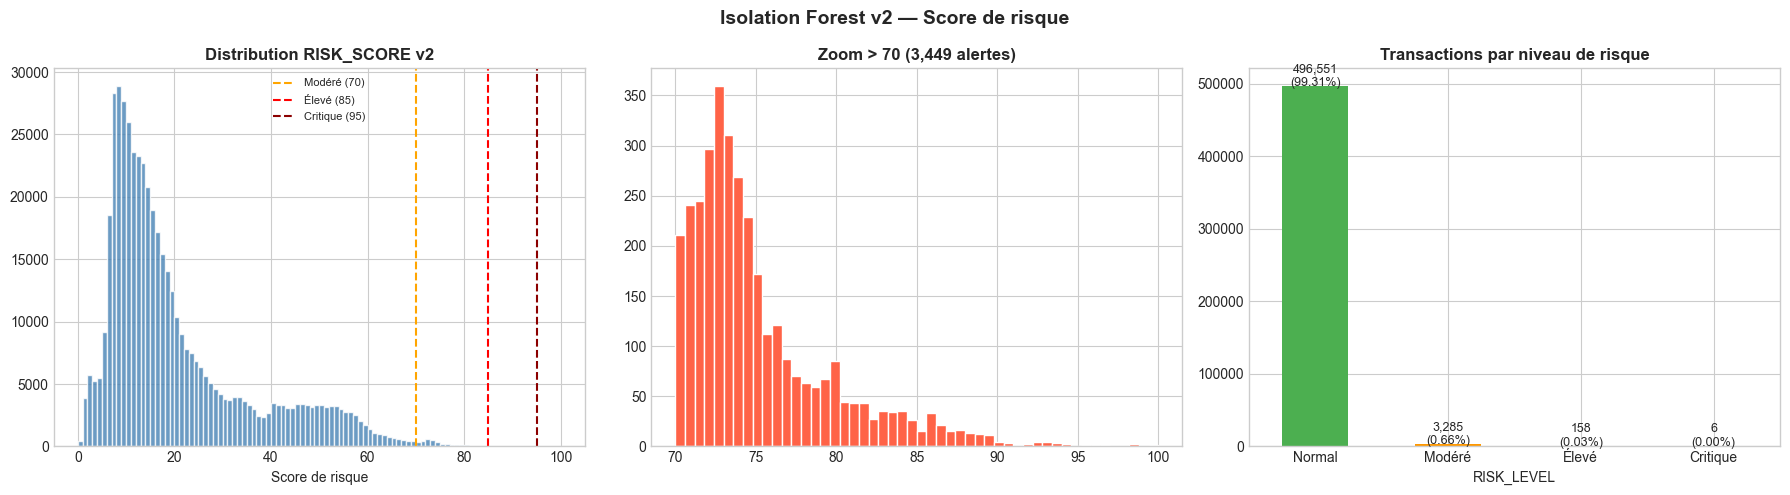

In [23]:
scores_inv = -scores_bruts
s_min, s_max = scores_inv.min(), scores_inv.max()
risk_score = ((scores_inv - s_min) / (s_max - s_min) * 100).clip(0, 100)

df_feat['RISK_SCORE']    = risk_score
df_feat['IS_ANOMALY_IF'] = (predictions == -1).astype(int)

SEUIL_MOYEN    = 70
SEUIL_ELEVE    = 85
SEUIL_CRITIQUE = 95

df_feat['RISK_LEVEL'] = pd.cut(
    df_feat['RISK_SCORE'],
    bins=[0, SEUIL_MOYEN, SEUIL_ELEVE, SEUIL_CRITIQUE, 100],
    labels=['Normal', 'Modéré', 'Élevé', 'Critique'],
    include_lowest=True
)

print('Distribution du RISK_SCORE v2 :')
print(pd.Series(risk_score).describe(percentiles=[.5,.75,.9,.95,.99]).round(2))
print('\nRépartition par niveau :')
vc = df_feat['RISK_LEVEL'].value_counts().sort_index()
print(vc)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(risk_score, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
for s, c, l in [(SEUIL_MOYEN,'orange','Modéré'),
                (SEUIL_ELEVE,'red','Élevé'),
                (SEUIL_CRITIQUE,'darkred','Critique')]:
    axes[0].axvline(s, color=c, linestyle='--', label=f'{l} ({s})')
axes[0].set_title('Distribution RISK_SCORE v2', fontweight='bold')
axes[0].set_xlabel('Score de risque')
axes[0].legend(fontsize=8)

high = risk_score[risk_score > SEUIL_MOYEN]
axes[1].hist(high, bins=50, color='tomato', edgecolor='white')
axes[1].set_title(f'Zoom > {SEUIL_MOYEN} ({len(high):,} alertes)', fontweight='bold')

colors_bar = ['#4CAF50','#FF9800','#F44336','#B71C1C']
vc.plot(kind='bar', ax=axes[2], color=colors_bar)
axes[2].set_title('Transactions par niveau de risque', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)
for i, v in enumerate(vc):
    axes[2].text(i, v + 200, f'{v:,}\n({v/len(df_feat)*100:.2f}%)', ha='center', fontsize=9)

plt.suptitle('Isolation Forest v2 — Score de risque', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'IF_v2_score_distribution.png', dpi=150)
plt.show()

## 10. Calibration — pseudo-labels corrigés

**FIX 2 :** Règle R2 désactivée pour RC et CASHIN.

In [24]:
conditions = pd.Series(False, index=df_feat.index)

# R1 : nuit + montant > p95
seuil_p95 = df_feat[COL_MONTANT].quantile(0.95)
r1 = (df_feat['f_est_nuit'] == 1) & (df_feat[COL_MONTANT] > seuil_p95)
conditions |= r1
print(f'R1 (nuit + montant > p95={seuil_p95:,.0f})     : {r1.sum():,} ({r1.mean()*100:.3f}%)')

# R2 CORRIGÉ : exclure RC, CASHIN, B2BCASHOUT
mask_avec_solde = ~df_feat[COL_SERVICE].isin(SERVICES_SANS_SOLDE)
r2 = mask_avec_solde & (df_feat['f_ratio_montant_solde'] > 0.95)
conditions |= r2
print(f'R2 CORRIGÉ (ratio > 95%, hors RC/CASHIN)       : {r2.sum():,} ({r2.mean()*100:.3f}%)')

# R3 : taux d'échec > 50% puis TS
r3 = (df_feat['f_taux_echec_journee'] > 0.5) & (df_feat[COL_STATUT] == 'TS')
conditions |= r3
print(f'R3 (taux échec > 50% puis TS)                  : {r3.sum():,} ({r3.mean()*100:.3f}%)')

# R4 : montant très arrondi + nuit
r4 = (df_feat['f_montant_tres_arrondi'] == 1) & (df_feat['f_est_nuit'] == 1)
conditions |= r4
print(f'R4 (montant×10k + nuit)                        : {r4.sum():,} ({r4.mean()*100:.3f}%)')

# R5 : nb destinataires distincts très élevé
seuil_dest = df_feat['f_nb_dest_journee'].quantile(0.99)
r5 = df_feat['f_nb_dest_journee'] > seuil_dest
conditions |= r5
print(f'R5 (nb destinataires > p99={seuil_dest:.0f})          : {r5.sum():,} ({r5.mean()*100:.3f}%)')

# R6 : montant cumulé journée très élevé (> p99)
seuil_cumul = df_feat['f_montant_cumul_journee'].quantile(0.99)
r6 = df_feat['f_montant_cumul_journee'] > seuil_cumul
conditions |= r6
print(f'R6 (montant cumulé > p99={seuil_cumul:,.0f}) : {r6.sum():,} ({r6.mean()*100:.3f}%)')

# R7 : rang > 50 dans la journée (compte très actif = potentiel mule)
r7 = df_feat['f_rang_tx_compte'] > 50
conditions |= r7
print(f'R7 (rang > 50 dans journée)                    : {r7.sum():,} ({r7.mean()*100:.3f}%)')

df_feat['PSEUDO_LABEL'] = conditions.astype(int)
n_pseudo = df_feat['PSEUDO_LABEL'].sum()
print(f'\nTotal pseudo-fraudes v2 : {n_pseudo:,} ({n_pseudo/len(df_feat)*100:.3f}%)')

R1 (nuit + montant > p95=254,500)     : 311 (0.062%)
R2 CORRIGÉ (ratio > 95%, hors RC/CASHIN)       : 56,787 (11.357%)
R3 (taux échec > 50% puis TS)                  : 1,752 (0.350%)
R4 (montant×10k + nuit)                        : 1,363 (0.273%)
R5 (nb destinataires > p99=200)          : 0 (0.000%)
R6 (montant cumulé > p99=373,726,666) : 5,000 (1.000%)
R7 (rang > 50 dans journée)                    : 44,821 (8.964%)

Total pseudo-fraudes v2 : 103,458 (20.692%)


Meilleur seuil F1    : 31.7
Precision            : 0.599
Recall               : 0.569
F1                   : 0.584

→ SEUIL OPÉRATIONNEL v2 : 70.0


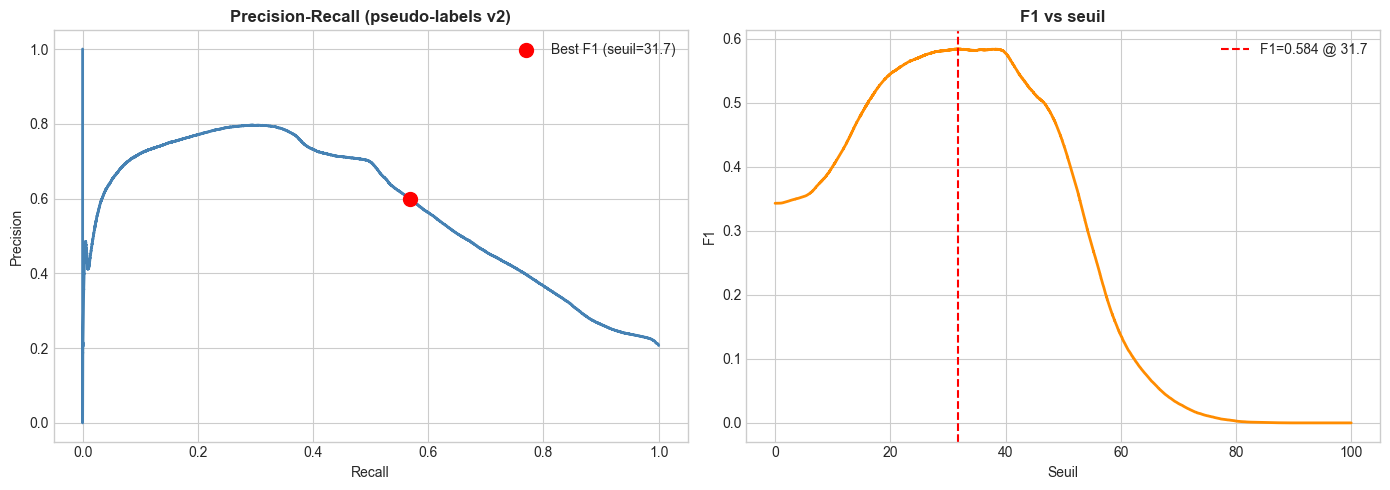

In [25]:
from sklearn.metrics import precision_recall_curve

y_true  = df_feat['PSEUDO_LABEL'].values
y_score = df_feat['RISK_SCORE'].values

precision, recall, thresholds = precision_recall_curve(y_true, y_score)
f1_scores   = 2 * precision * recall / (precision + recall + 1e-9)
best_idx    = np.argmax(f1_scores)
best_seuil  = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

print(f'Meilleur seuil F1    : {best_seuil:.1f}')
print(f'Precision            : {precision[best_idx]:.3f}')
print(f'Recall               : {recall[best_idx]:.3f}')
print(f'F1                   : {f1_scores[best_idx]:.3f}')

SEUIL_OPERATIONNEL = max(float(best_seuil), 70.0)
print(f'\n→ SEUIL OPÉRATIONNEL v2 : {SEUIL_OPERATIONNEL:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(recall, precision, color='steelblue', lw=2)
axes[0].scatter(recall[best_idx], precision[best_idx], color='red', s=100, zorder=5,
                label=f'Best F1 (seuil={best_seuil:.1f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall (pseudo-labels v2)', fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, f1_scores[:-1], color='darkorange', lw=2)
axes[1].axvline(best_seuil, color='red', linestyle='--',
                label=f'F1={f1_scores[best_idx]:.3f} @ {best_seuil:.1f}')
axes[1].set_xlabel('Seuil'); axes[1].set_ylabel('F1')
axes[1].set_title('F1 vs seuil', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'IF_v2_calibration.png', dpi=150)
plt.show()

## 11. Analyse des alertes

In [26]:
alertes = df_feat[df_feat['RISK_SCORE'] >= SEUIL_OPERATIONNEL].copy()
print(f'Alertes (score ≥ {SEUIL_OPERATIONNEL:.0f}) : {len(alertes):,} ({len(alertes)/len(df_feat)*100:.2f}%)')

cols_affichage = [COL_DATE, COL_SENDER_ID, COL_MSISDN, COL_RECVR,
                  COL_MONTANT, COL_SERVICE, COL_STATUT,
                  'RISK_SCORE', 'RISK_LEVEL', 'PSEUDO_LABEL']
cols_affichage = [c for c in cols_affichage if c in alertes.columns]

print('\nTop 25 alertes :')
display(alertes.nlargest(25, 'RISK_SCORE')[cols_affichage])

Alertes (score ≥ 70) : 3,449 (0.69%)

Top 25 alertes :


,CREATED_ON,SENDER_USER_ID,INITIATOR_MSISDN,OTHER_MSISDN,TRANSACTION_AMOUNT,SERVICE_TYPE,TRANSFER_STATUS,RISK_SCORE,RISK_LEVEL,PSEUDO_LABEL
271647,2025-09-20 15:37:27,PT230530.1643.066714,NaN,NaN,"1,000,000.0000",P2P,TF,100.0000,Critique,0
190497,2025-09-20 15:37:51,PT211112.0927.329961,NaN,NaN,"500,000.0000",P2P,TF,98.3516,Critique,0
190496,2025-09-20 15:36:41,PT211112.0927.329961,NaN,NaN,"500,000.0000",P2P,TF,98.2325,Critique,0
30375,2025-09-20 11:33:40,PT131111.1327.A00213,NaN,NaN,"220,000.0000",P2P,TF,96.7628,Critique,0
144306,2025-09-20 12:42:30,PT200512.0829.097436,NaN,NaN,"400,000.0000",P2P,TF,96.0573,Critique,0
360254,2025-09-20 07:32:24,PT240618.1223.356046,NaN,NaN,"1,670,700.0000",CASHOUT,TF,95.2530,Critique,0
180007,2025-09-20 08:33:51,PT210802.0820.218264,NaN,NaN,"330,000.0000",P2P,TF,94.4951,Élevé,0
430782,2025-09-20 12:13:57,PT250305.1045.775901,NaN,NaN,"700,000.0000",P2P,TF,94.1936,Élevé,0
344490,2025-09-20 10:22:35,PT240418.1401.582620,NaN,NaN,"500,000.0000",P2P,TF,93.5894,Élevé,0
393273,2025-09-20 08:47:02,PT241016.1713.244311,NaN,NaN,"2,000,000.0000",P2P,TF,93.5012,Élevé,0


In [27]:
# Analyse par service
alerte_service = alertes.groupby(COL_SERVICE).agg(
    nb_alertes=('RISK_SCORE','count'),
    score_moyen=('RISK_SCORE','mean'),
    score_max=('RISK_SCORE','max'),
    montant_total=(COL_MONTANT,'sum'),
    montant_moyen=(COL_MONTANT,'mean')
).round(2)
total_par_service = df_feat.groupby(COL_SERVICE).size().rename('nb_total')
alerte_service = alerte_service.join(total_par_service)
alerte_service['taux_pct'] = (alerte_service['nb_alertes'] / alerte_service['nb_total'] * 100).round(2)
print('=== Alertes par SERVICE_TYPE ===')
print(alerte_service.sort_values('nb_alertes', ascending=False))

# Comparaison v1 vs v2
print('\n=== Comparaison v1 vs v2 ===')
print(f'  v1 : alertes critiques (≥95) = 45 | total alertes = 6,983')
print(f'  v2 : alertes critiques (≥95) = {(df_feat["RISK_SCORE"]>=95).sum():,} | total alertes = {len(alertes):,}')

# Alertes par heure
alertes['_heure'] = pd.to_datetime(alertes[COL_DATE], errors='coerce').dt.hour
print('\n=== Alertes par heure ===')
print(alertes['_heure'].value_counts().sort_index())

=== Alertes par SERVICE_TYPE ===
              nb_alertes  score_moyen  score_max      montant_total  \
SERVICE_TYPE                                                          
RC                  1133      73.8900    93.3200    34,340,100.0000   
CASHOUT              991      76.4400    95.2500   246,009,453.8100   
CASHIN               639      74.6500    89.3000 1,012,210,326.7500   
P2P                  580      76.1500   100.0000 4,367,195,160.1900   
MERCHPAY              90      73.5500    86.1800    66,081,110.1600   
TXNCORRECT            11      74.5800    78.9400    10,336,000.0000   
OPTW                   4      78.9400    80.5400   400,000,000.0000   
COUTBYCODE             1      73.3300    73.3300             0.0000   

                montant_moyen  nb_total  taux_pct  
SERVICE_TYPE                                       
RC                30,309.0000    144497    0.7800  
CASHOUT          248,243.6500     89861    1.1000  
CASHIN         1,584,053.7200     86874    0.740

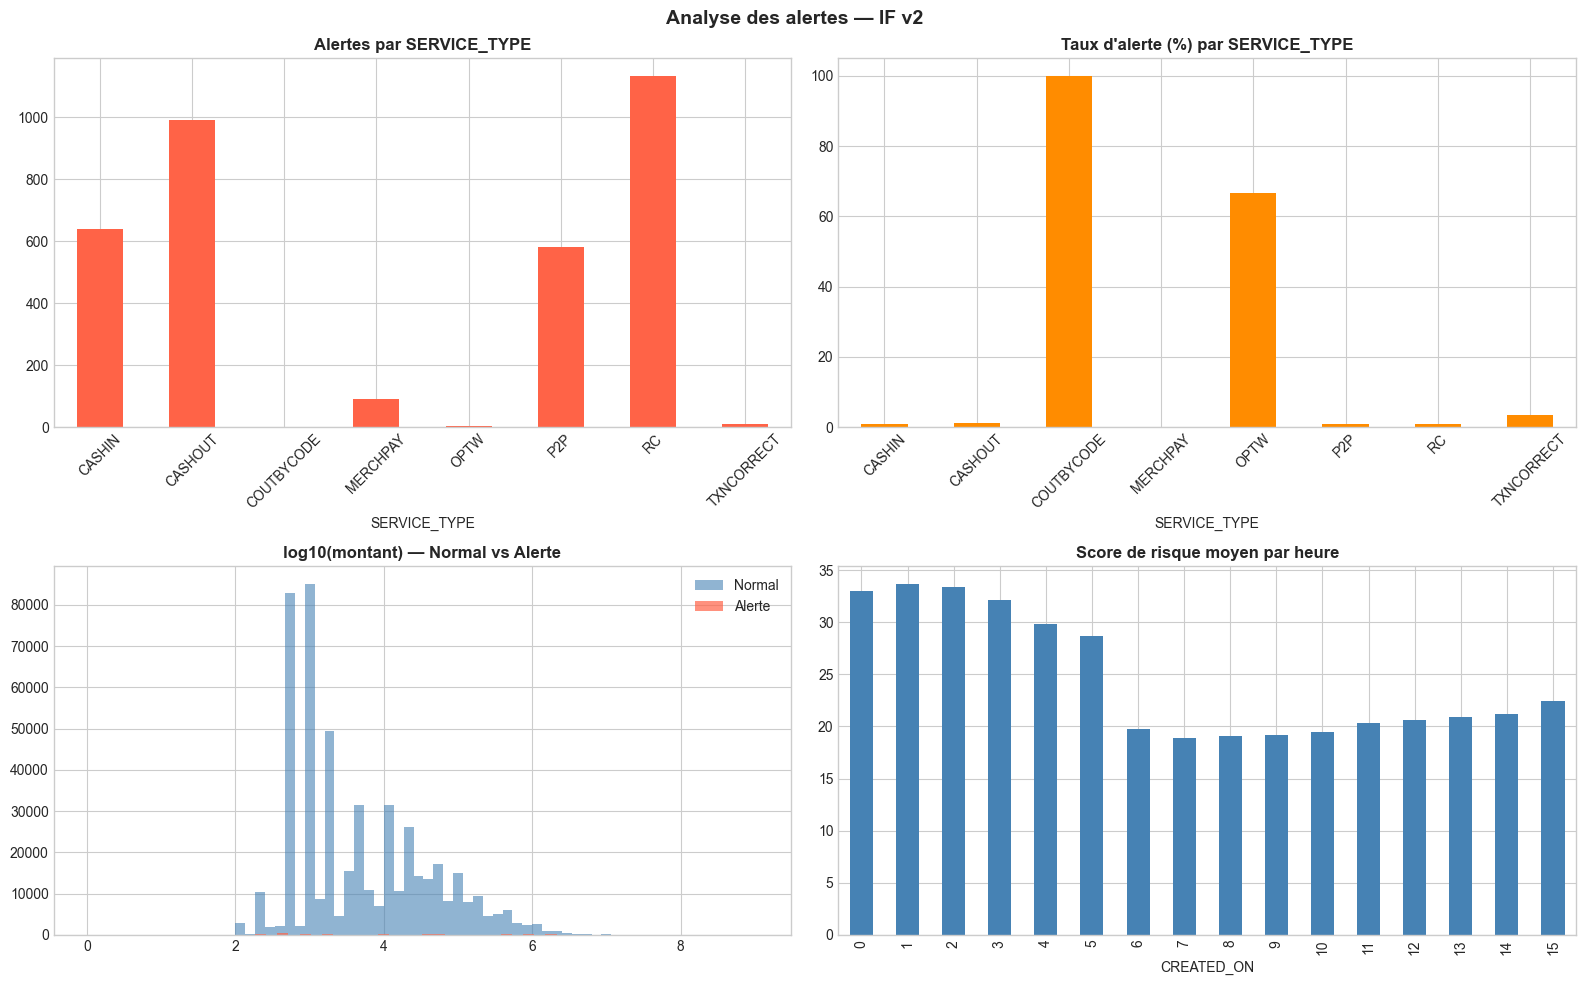

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

alerte_service['nb_alertes'].plot(kind='bar', ax=axes[0,0], color='tomato')
axes[0,0].set_title('Alertes par SERVICE_TYPE', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

alerte_service['taux_pct'].plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Taux d\'alerte (%) par SERVICE_TYPE', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

normal  = df_feat[df_feat['RISK_SCORE'] < SEUIL_OPERATIONNEL][COL_MONTANT]
suspect = alertes[COL_MONTANT]
axes[1,0].hist(np.log10(normal.clip(lower=1)),  bins=60, alpha=0.6, label='Normal',  color='steelblue')
axes[1,0].hist(np.log10(suspect.clip(lower=1)), bins=60, alpha=0.7, label='Alerte',  color='tomato')
axes[1,0].set_title('log10(montant) — Normal vs Alerte', fontweight='bold')
axes[1,0].legend()

score_par_heure = df_feat.groupby(
    pd.to_datetime(df_feat[COL_DATE], errors='coerce').dt.hour
)['RISK_SCORE'].mean()
score_par_heure.plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Score de risque moyen par heure', fontweight='bold')

plt.suptitle('Analyse des alertes — IF v2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'IF_v2_alertes.png', dpi=150)
plt.show()

## 12. Importance des features (perturbation)

Calcul importance des features...
Calculé en 53.7s


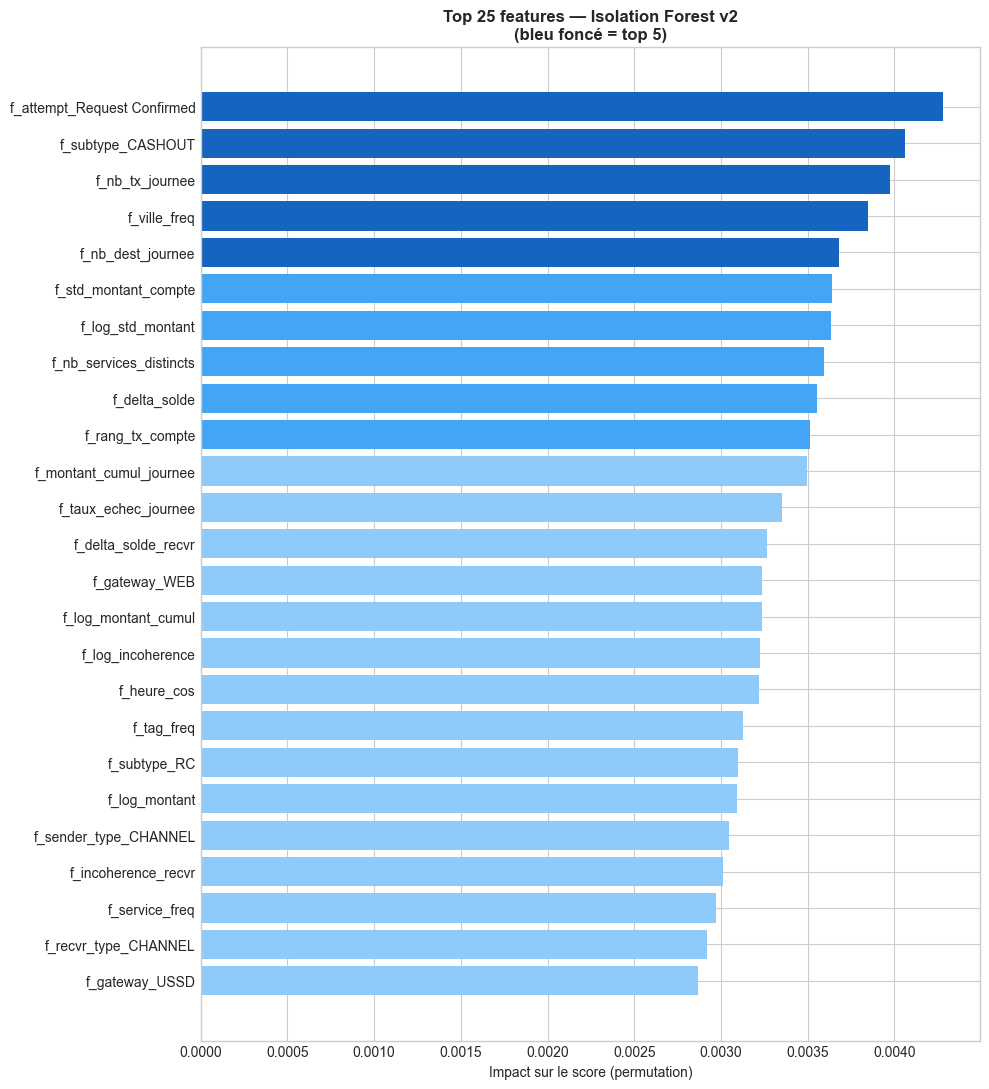


Top 15 features :
                    feature  importance
f_attempt_Request Confirmed      0.0043
          f_subtype_CASHOUT      0.0041
            f_nb_tx_journee      0.0040
               f_ville_freq      0.0038
          f_nb_dest_journee      0.0037
       f_std_montant_compte      0.0036
          f_log_std_montant      0.0036
    f_nb_services_distincts      0.0036
              f_delta_solde      0.0036
           f_rang_tx_compte      0.0035
    f_montant_cumul_journee      0.0035
       f_taux_echec_journee      0.0034
        f_delta_solde_recvr      0.0033
              f_gateway_WEB      0.0032
        f_log_montant_cumul      0.0032


In [29]:
print('Calcul importance des features...')
debut = time.time()

idx_sample = np.random.RandomState(42).choice(len(X_scaled), size=50_000, replace=False)
X_sub      = X_scaled[idx_sample]
score_ref  = iso_forest.score_samples(X_sub)

importances_perm = []
for j, feat in enumerate(FEATURE_COLS):
    X_perm = X_sub.copy()
    np.random.shuffle(X_perm[:, j])
    score_perm = iso_forest.score_samples(X_perm)
    importances_perm.append({'feature': feat, 'importance': np.abs(score_ref - score_perm).mean()})

df_imp = pd.DataFrame(importances_perm).sort_values('importance', ascending=False)
print(f'Calculé en {time.time()-debut:.1f}s')

top_n = min(25, len(df_imp))
fig, ax = plt.subplots(figsize=(10, top_n * 0.4 + 1))
colors = ['#1565C0' if i < 5 else '#42A5F5' if i < 10 else '#90CAF9'
          for i in range(top_n)]
ax.barh(df_imp['feature'].head(top_n)[::-1],
        df_imp['importance'].head(top_n)[::-1],
        color=colors[::-1])
ax.set_title(f'Top {top_n} features — Isolation Forest v2\n(bleu foncé = top 5)',
             fontweight='bold')
ax.set_xlabel('Impact sur le score (permutation)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'IF_v2_feature_importance.png', dpi=150)
plt.show()

print(f'\nTop 15 features :')
print(df_imp.head(15).to_string(index=False))

## 13. Export

In [30]:
# Modèle + scaler
joblib.dump(iso_forest, OUTPUT_DIR / 'M1_isolation_forest_v2.pkl')
joblib.dump(scaler,     OUTPUT_DIR / 'M1_scaler_v2.pkl')
print('✅ Modèle & scaler sauvegardés')

# Dataset scoré complet
id_cols = ['TRANSFER_ID', COL_DATE, COL_SENDER_ID, COL_MSISDN,
           COL_RECVR, COL_MONTANT, COL_SERVICE, COL_STATUT, COL_VILLE]
id_cols = [c for c in id_cols if c in df_feat.columns]
score_cols = ['RISK_SCORE', 'RISK_LEVEL', 'IS_ANOMALY_IF', 'PSEUDO_LABEL']
cols_export = id_cols + score_cols + FEATURE_COLS
cols_export = list(dict.fromkeys(cols_export))  # dédoublonnage

df_feat[cols_export].to_parquet(OUTPUT_DIR / 'M1_scored_v2.parquet', index=False)
print(f'✅ Dataset scoré : M1_scored_v2.parquet ({len(df_feat):,} lignes)')

# CSV alertes
alertes_export = df_feat[
    df_feat['RISK_SCORE'] >= SEUIL_OPERATIONNEL
][cols_export].sort_values('RISK_SCORE', ascending=False)
alertes_export.to_csv(OUTPUT_DIR / 'M1_alertes_v2.csv', index=False, encoding='utf-8-sig')
print(f'✅ Alertes : M1_alertes_v2.csv ({len(alertes_export):,} lignes)')

# Paramètres JSON
params = {
    'version'             : 'v2',
    'FEATURE_COLS'        : FEATURE_COLS,
    'n_features'          : len(FEATURE_COLS),
    'SEUIL_OPERATIONNEL'  : float(SEUIL_OPERATIONNEL),
    'SEUIL_MOYEN'         : SEUIL_MOYEN,
    'SEUIL_ELEVE'         : SEUIL_ELEVE,
    'SEUIL_CRITIQUE'      : SEUIL_CRITIQUE,
    'contamination'       : 0.01,
    'n_estimators'        : 300,
    'score_min'           : float(s_min),
    'score_max'           : float(s_max),
    'colonnes_reelles'    : {
        'COL_MONTANT'  : COL_MONTANT,
        'COL_S_AVANT'  : COL_S_AVANT,
        'COL_S_APRES'  : COL_S_APRES,
        'COL_SENDER_ID': COL_SENDER_ID,
        'COL_MSISDN'   : COL_MSISDN,
        'COL_RECVR'    : COL_RECVR,
        'COL_VILLE'    : COL_VILLE,
    },
    'services_sans_solde' : SERVICES_SANS_SOLDE,
    'fixes_appliques'     : [
        'FIX1: f_has_msisdn + Bloc C sur SENDER_USER_ID',
        'FIX2: ratio montant/solde desactive pour RC/CASHIN/B2BCASHOUT/ENT2REG',
        'FIX3: Bloc C recalcule sur SENDER_USER_ID (toujours rempli)'
    ]
}
with open(OUTPUT_DIR / 'M1_params_v2.json', 'w') as f:
    json.dump(params, f, indent=2)
print('✅ Paramètres : M1_params_v2.json')

print(f'\n{"+" * 65}')
print('RÉSUMÉ FINAL — M1 ISOLATION FOREST v2')
print(f'{"+" * 65}')
print(f'Transactions analysées    : {len(df_feat):,}')
print(f'Features utilisées        : {len(FEATURE_COLS)}')
print(f'Anomalies IF (1%)         : {n_anomalies:,}')
print(f'Seuil opérationnel        : {SEUIL_OPERATIONNEL:.0f}/100')
print(f'Alertes totales           : {len(alertes_export):,} ({len(alertes_export)/len(df_feat)*100:.2f}%)')
print(f'Alertes critiques (≥95)   : {(df_feat["RISK_SCORE"]>=95).sum():,}')
print(f'Pseudo-fraudes détectées  : {n_pseudo:,} ({n_pseudo/len(df_feat)*100:.3f}%)')
print(f'\nFixes appliqués :')
print(f'  ✅ FIX1 : Bloc C sur SENDER_USER_ID + f_has_msisdn')
print(f'  ✅ FIX2 : Ratio montant/solde exclu pour RC/CASHIN')
print(f'  ✅ FIX3 : NaN Bloc C éliminés (0 NaN attendu)')
print(f'\n→ Prêt pour : 03_M1_dashboard_integration.ipynb')

✅ Modèle & scaler sauvegardés
✅ Dataset scoré : M1_scored_v2.parquet (500,000 lignes)
✅ Alertes : M1_alertes_v2.csv (3,449 lignes)
✅ Paramètres : M1_params_v2.json

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
RÉSUMÉ FINAL — M1 ISOLATION FOREST v2
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Transactions analysées    : 500,000
Features utilisées        : 67
Anomalies IF (1%)         : 5,000
Seuil opérationnel        : 70/100
Alertes totales           : 3,449 (0.69%)
Alertes critiques (≥95)   : 6
Pseudo-fraudes détectées  : 103,458 (20.692%)

Fixes appliqués :
  ✅ FIX1 : Bloc C sur SENDER_USER_ID + f_has_msisdn
  ✅ FIX2 : Ratio montant/solde exclu pour RC/CASHIN
  ✅ FIX3 : NaN Bloc C éliminés (0 NaN attendu)

→ Prêt pour : 03_M1_dashboard_integration.ipynb
